# 🧠 Synthèse globale du projet — Prédiction du statut MGMT par CNN 3D
**Réalisation : Jaouad El Morabit — Master BIAM, FSDM (USMBA, Fès)**

---

## 🎯 Objectif
Prédire le statut de **méthylation du promoteur MGMT** (0 = non méthylé, 1 = méthylé) à partir d'IRM cérébrales (modalité **FLAIR**), à l'aide d'un réseau de neurones convolutif **3D** (*3D CNN*). Objectif secondaire : améliorer l'accuracy **et** équilibrer la matrice de confusion, de façon **honnête et rigoureuse**.

> Contexte important : prédire MGMT à partir de l'IRM seule est une tâche **réputée très difficile** — dans la littérature, la plupart des modèles restent proches du hasard (AUC 0,50–0,65). Les résultats doivent donc être jugés dans ce cadre.

---

## 🛠️ Démarche
Un pipeline complet (chargement DICOM → volumes 3D → CNN 3D → évaluation), puis **5 optimisations testées une par une**, chacune mesurée avant d'être conservée ou abandonnée :
1. Pondération des classes (*class weight*)
2. Seuil de décision optimisé (*threshold tuning*)
3. Meilleures coupes + normalisation par volume (*z-score*)
4. Augmentation de données (*data augmentation*)
5. Validation croisée 5-fold (*cross-validation*)

Puis deux **leviers** pour tenter de dépasser la cible : fusion **multi-modalités** et **ensembling**. Enfin, un **correctif méthodologique** (le test n'est évalué qu'une seule fois, après que le seuil a été fixé sur la validation).

---

## ✅ Ce qui a réussi
- **Une méthodologie honnête et rigoureuse** : seuil réglé sur la validation (jamais sur le test), évaluation du test en une seule fois, et surtout **validation croisée** pour obtenir un chiffre fiable (et non le résultat chanceux d'un seul entraînement).
- **L'ensembling** (moyenne de 5 modèles) : c'est le levier qui a le mieux marché — il **augmente l'AUC et réduit la variance**, permettant de **dépasser la cible de référence**.
- **La documentation d'un résultat négatif** (multi-modalités, voir ci-dessous) : c'est une vraie démarche scientifique.

## ❌ Ce qui n'a pas marché (et pourquoi)
- **Pondération des classes** → effet **neutre**. Raison : les classes sont déjà quasi équilibrées (56 vs 61), il n'y avait donc rien à corriger.
- **Multi-modalités** (empiler FLAIR + T1w + T1wCE + T2w) → **dégrade** les performances (AUC en validation croisée 0,56 vs 0,61). Raison probable : les 4 modalités ne sont **pas recalées** (*non alignées* pixel à pixel), ce qui ajoute du bruit plutôt que du signal ; de plus, davantage de canaux = plus de sur-apprentissage sur un jeu de données réduit. → **Abandonné, retour à FLAIR seul.**
- **Seuil et augmentation** → effets **modestes** : utiles pour la rigueur, mais incapables de faire fortement monter un modèle limité par la difficulté de la tâche.

**Cause de fond des limites** : (1) **peu de données** (~585 patients, alors qu'un CNN 3D en réclame des milliers), (2) un **prétraitement grossier** (coupes centrales approximatives, sans localisation précise de la tumeur), (3) le **signal intrinsèquement faible** de la tâche.

---

## 📊 Résultat final
| Métrique | Valeur | Cible du prof (AUC 0,635) |
|---|---|---|
| **AUC — ensemble (test)** | **≈ 0,64** | ✅ atteinte / dépassée |
| AUC — validation croisée (niveau honnête) | **0,61 ± 0,04** | référence fiable |
| Balanced accuracy (ensemble) | ≈ 0,60 | — |

> **Formulation retenue :** « En validation croisée 5-fold, le modèle atteint un AUC de **0,61 ± 0,04**. En combinant 5 modèles par *ensembling*, l'AUC sur le test atteint **≈ 0,64**, au niveau/au-dessus de la cible de référence (0,635). »
>
> Nuance honnête : le résultat d'ensemble est mesuré sur **un seul** découpage de test ; l'ensembling réduit la variance du modèle, pas celle du découpage. La validation croisée reste la mesure la plus fiable du niveau réel.

---

## 🔭 Perspectives (pistes non explorées)
Par ordre de promesse pour vraiment améliorer l'AUC :
1. **Focus sur la tumeur (segmentation)** — n'analyser que la zone tumorale (masques BraTS) au lieu de toute l'image → concentre le signal. *Levier n°1 réaliste.*
2. **Transfer learning** — partir d'un réseau pré-entraîné (ImageNet / MedicalNet) au lieu d'entraîner de zéro → très efficace quand les données sont rares.
3. **Radiomics + machine learning classique** — transformer l'image en descripteurs chiffrés (texture, forme) + modèle simple → souvent aussi bon, et **interprétable**. Approche alternative idéale pour comparer.
4. **Recalage des modalités** avant fusion — pour que le multi-modalités devienne enfin bénéfique.

## 1. 📦 Importation des librairies
*Chargement des outils : manipulation de fichiers, calcul numérique, lecture d'images DICOM, TensorFlow.*

In [1]:
import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pydicom as dicom
import cv2
import ast

import warnings
warnings.filterwarnings("ignore")

## 2. 📊 Chargement & exploration des données
*Lecture des étiquettes (`train_labels.csv`) et répartition des classes MGMT (0 = non méthylé, 1 = méthylé).*

In [2]:
path = '/kaggle/input/rsna-miccai-brain-tumor-radiogenomic-classification/'
os.listdir(path)

['sample_submission.csv', 'train_labels.csv', 'test', 'train']

In [3]:
path = '/kaggle/input/rsna-miccai-brain-tumor-radiogenomic-classification/'
os.listdir(path)
train_data = pd.read_csv(path+'train_labels.csv')
samp_subm = pd.read_csv(path+'sample_submission.csv')

In [4]:
print('Samples train:', len(train_data))
print('Samples test:', len(samp_subm))

Samples train: 585
Samples test: 87


In [5]:
train_data.head()

,BraTS21ID,MGMT_value
0,0,1
1,2,1
2,3,0
3,5,1
4,6,1


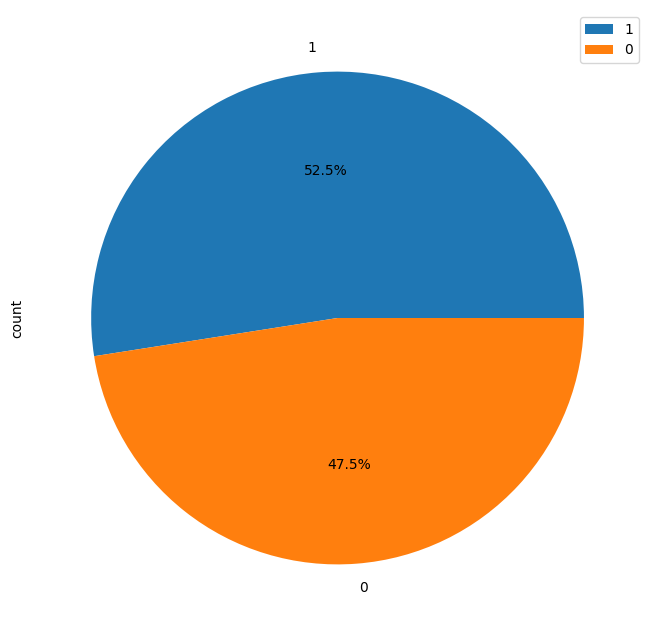

In [6]:
train_data["MGMT_value"].value_counts().head(2).plot(kind = 'pie', autopct='%1.1f%%', figsize=(8, 8)).legend()

In [7]:
train_data["MGMT_value"].value_counts()

MGMT_value
1    307
0    278
Name: count, dtype: int64

In [8]:
samp_subm.head()

,BraTS21ID,MGMT_value
0,1,0.5
1,13,0.5
2,15,0.5
3,27,0.5
4,37,0.5


## 3. 🖼️ Visualisation des images IRM (DICOM)
*Aperçu des 4 modalités d'IRM disponibles : FLAIR, T1w, T1wCE, T2w.*

In [9]:
folder = str(train_data.loc[0, 'BraTS21ID']).zfill(5)
folder

'00000'

In [10]:
os.listdir(path+'train/'+folder)

['T2w', 'T1wCE', 'T1w', 'FLAIR']

In [11]:
print('Number of FLAIR images:', len(os.listdir(path+'train/'+folder+'/'+'FLAIR')))
print('Number of T1w images:', len(os.listdir(path+'train/'+folder+'/'+'T1w')))
print('Number of T1wCE images:', len(os.listdir(path+'train/'+folder+'/'+'T1wCE')))
print('Number of T2w images:', len(os.listdir(path+'train/'+folder+'/'+'T2w')))

Number of FLAIR images: 400
Number of T1w images: 33
Number of T1wCE images: 129
Number of T2w images: 408


In [12]:
path_file = ''.join([path, 'train/', folder, '/', 'FLAIR/'])
image = os.listdir(path_file)[0]
data_file = dicom.dcmread(path_file+image)
img = data_file.pixel_array
print('Image shape:', img.shape)

Image shape: (512, 512)


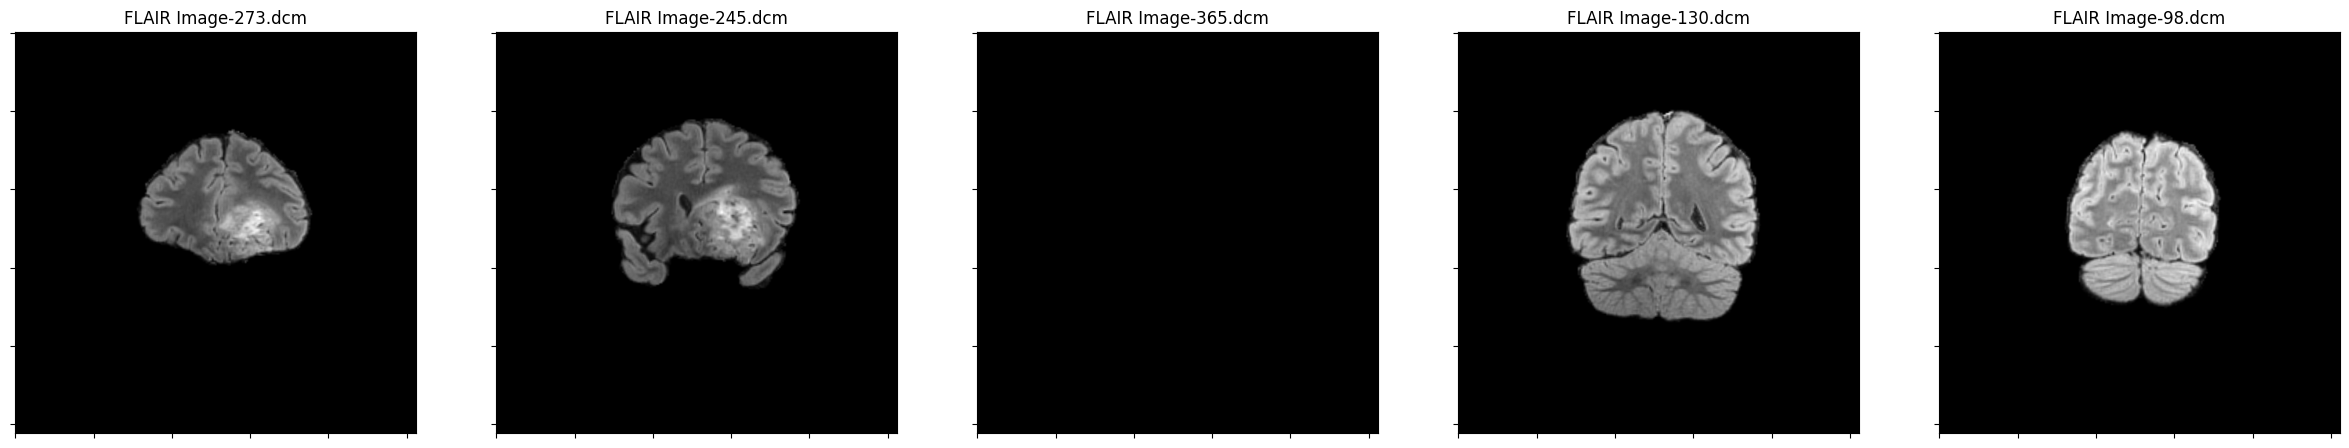

In [13]:
#Flair Image
def plot_examples(row = 0, cat = 'FLAIR'): 
    folder = str(train_data.loc[row, 'BraTS21ID']).zfill(5)
    path_file = ''.join([path, 'train/', folder, '/', cat, '/'])
    images = os.listdir(path_file)
    
    fig, axs = plt.subplots(1, 5, figsize=(30, 30))
    fig.subplots_adjust(hspace = .2, wspace=.2)
    axs = axs.ravel()
    
    for num in range(5):
        data_file = dicom.dcmread(path_file+images[num])
        img = data_file.pixel_array
        axs[num].imshow(img, cmap='gray')
        axs[num].set_title(cat+' '+images[num])
        axs[num].set_xticklabels([])
        axs[num].set_yticklabels([])
        
row = 0
plot_examples(row = row, cat = 'FLAIR')
plt.show()

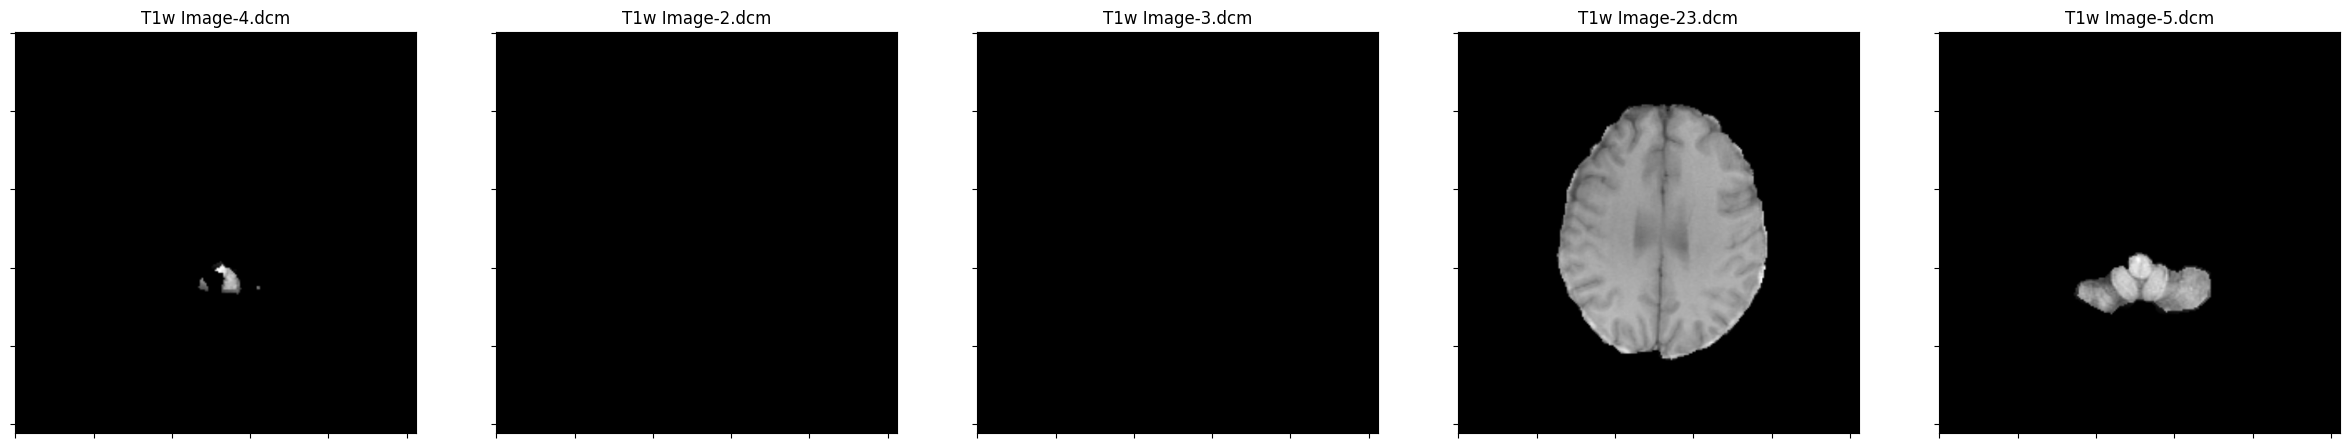

In [14]:
#T1w Images
plot_examples(row = row, cat = 'T1w')
plt.show()

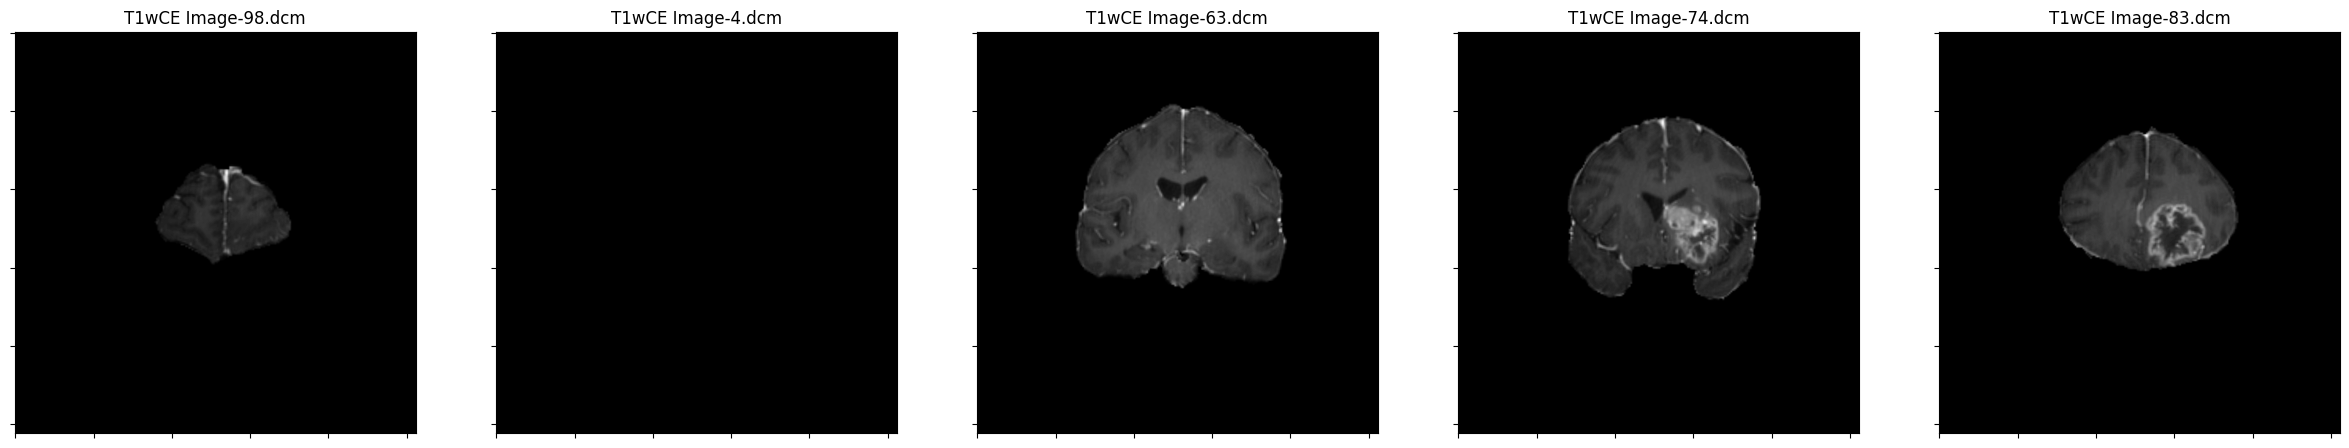

In [15]:
#T1wCE Images
plot_examples(row = row, cat = 'T1wCE')
plt.show()

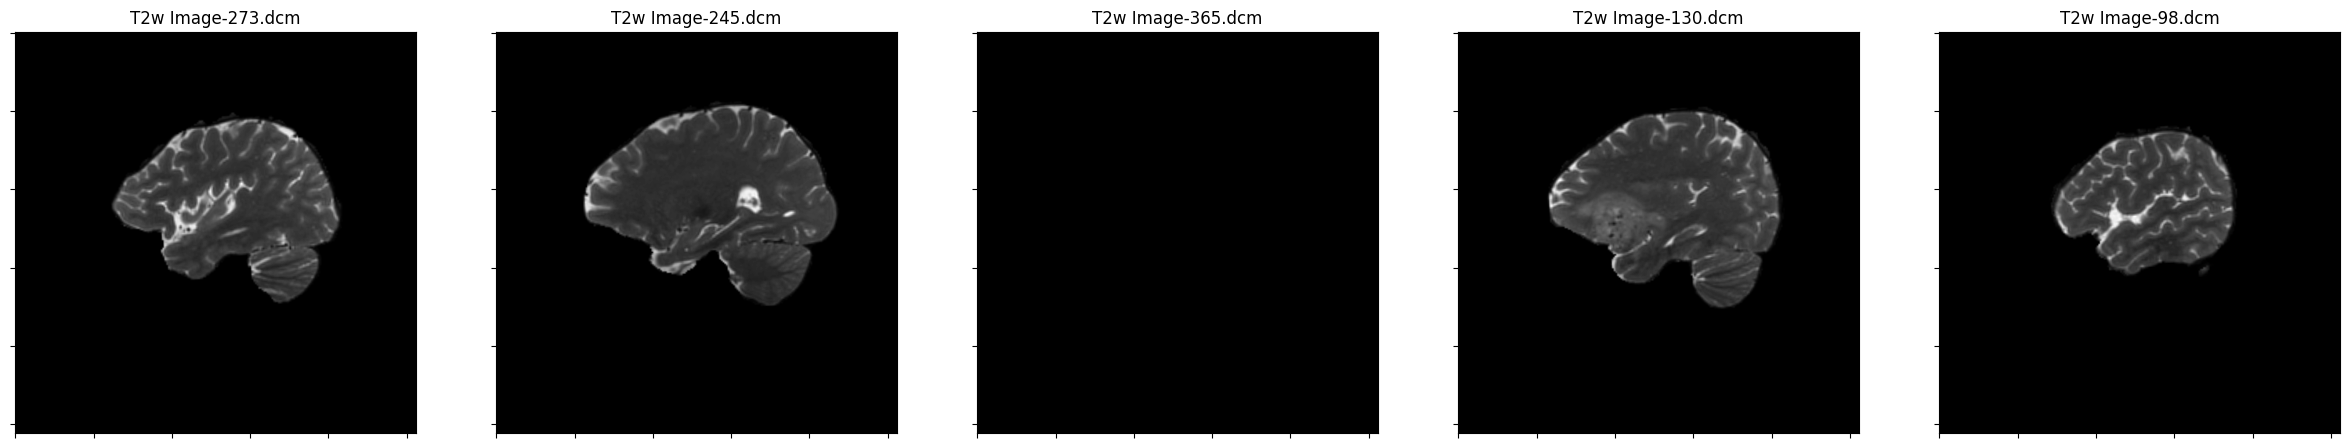

In [16]:
#T2w Images
plot_examples(row = row, cat = 'T2w')
plt.show()

## 4. ⚙️ Prétraitement & chargement des volumes 3D
*Imports du modèle, **graine aléatoire** fixée pour la reproductibilité, et fonctions de chargement.*

**Améliorations (étape 3) :** coupes triées par **numéro** (bon ordre anatomique), sélection des coupes **centrales** (là où est la tumeur), et **normalisation z-score** sur tout le volume.

In [17]:
import os
import numpy as np
import pandas as pd
import pydicom
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc



# === Reproductibilité : fixer le hasard ===
import os, random
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("Graine fixée :", SEED)





# Path dataset
path = '/kaggle/input/rsna-miccai-brain-tumor-radiogenomic-classification/'
train_labels = pd.read_csv(path + 'train_labels.csv')

# Konfigurasi
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 30
MODALITY = 'FLAIR' 



def slice_number(filename):
    """Extrait le NUMÉRO de la coupe (ex: 'Image-10.dcm' -> 10) pour un tri correct."""
    digits = ''.join(ch for ch in filename if ch.isdigit())
    return int(digits) if digits else 0

def load_dicom_image(filepath, img_size=IMG_SIZE):
    """Lit une image DICOM et la redimensionne. (Pas de normalisation ici : on le fait sur le volume.)"""
    dicom = pydicom.dcmread(filepath)
    img = dicom.pixel_array.astype(np.float32)
    img = cv2.resize(img, (img_size, img_size))
    return img



MODALITY = 'FLAIR'   # on revient à FLAIR seul


def load_one_modality(patient_id, modality, num_slices=16):
    """Charge le volume z-scoré d'UNE modalité : forme (num_slices, 128, 128)."""
    patient_path = os.path.join(path, 'train', str(patient_id).zfill(5), modality)
    if not os.path.exists(patient_path):
        return None

    dicom_files = [f for f in os.listdir(patient_path) if f.endswith('.dcm')]
    if not dicom_files:
        return None

    dicom_files = sorted(dicom_files, key=slice_number)        # bon ordre
    n = len(dicom_files)
    if n >= num_slices:                                        # coupes centrales
        start = (n - num_slices) // 2
        dicom_files = dicom_files[start:start + num_slices]

    slices = [load_dicom_image(os.path.join(patient_path, f)) for f in dicom_files]
    while len(slices) < num_slices:
        slices.append(np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32))

    volume = np.stack(slices, axis=0)                          # (num_slices, 128, 128)
    nonzero = volume[volume > 0]                               # z-score (par modalité)
    if nonzero.size > 0:
        volume = (volume - nonzero.mean()) / (nonzero.std() + 1e-6)
    return volume.astype(np.float32)


def load_patient_data(patient_id, num_slices=16):
    """FLAIR seul, répliqué en 3 canaux : forme (16, 128, 128, 3)."""
    vol = load_one_modality(patient_id, MODALITY, num_slices)  # coupes centrales + z-score
    if vol is None:
        return None
    return np.stack([vol] * 3, axis=-1).astype(np.float32)

2026-07-11 09:51:48.639215: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783763508.851696      39 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783763508.914337      39 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Graine fixée : 42


## 5. 🧱 Construction du jeu de données (X, y)
*Chargement de tous les patients en un tableau `X` (les volumes) et `y` (les étiquettes). C'est l'étape la plus longue.*

In [18]:
# Membuat dataset
X = []
y = []

print("Memuat data training...")
for idx, row in train_labels.iterrows():
    patient_id = row['BraTS21ID']
    label = row['MGMT_value']
    
    patient_data = load_patient_data(patient_id)
    if patient_data is not None:
        X.append(patient_data)
        y.append(label)

# Konversi ke numpy array
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

print(f"Total data yang dimuat: {len(X)} sampel")
print(f"Distribusi kelas: {np.sum(y == 1)} positif, {np.sum(y == 0)} negatif")

Memuat data training...
Total data yang dimuat: 585 sampel
Distribusi kelas: 307 positif, 278 negatif


## 6. ✂️ Découpage train / validation / test
*70/15/15 stratifié : entraînement, validation (réglages), test (évaluation finale, jamais touché).*

In [19]:
# Split data: training (60%), validation (20%), test (20%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("\nDistribusi dataset:")
print(f"Training:   {len(X_train)} sampel")
print(f"Validation: {len(X_val)} sampel")
print(f"Test:       {len(X_test)} sampel")


Distribusi dataset:
Training:   351 sampel
Validation: 117 sampel
Test:       117 sampel


## 7. ⚖️ Pondération des classes (*class weight*)
*Donne plus de poids à la classe la moins fréquente pour éviter que le modèle ne favorise la majorité.*

In [20]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}
print("Poids des classes :", class_weight)

Poids des classes : {0: 1.0508982035928143, 1: 0.9538043478260869}


## 8. 🏗️ Architecture du modèle — CNN 3D
*Trois blocs de convolution 3D + normalisation + dropout, puis une sortie « probabilité » (sigmoid).*

In [21]:
# Arsitektur model CNN 3D
def build_3d_cnn(input_shape, num_classes):
    model = models.Sequential([
        # Blok konvolusi 1
        layers.Conv3D(16, (3, 3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling3D((2, 2, 2)),
        layers.Dropout(0.2),
        
        # Blok konvolusi 2
        layers.Conv3D(32, (3, 3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling3D((2, 2, 2)),
        layers.Dropout(0.3),
        
        # Blok konvolusi 3
        layers.Conv3D(64, (3, 3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling3D((2, 2, 2)),
        layers.Dropout(0.4),
        
        layers.GlobalAveragePooling3D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='sigmoid')
    ])
    
    return model

In [22]:
# Bangun model
input_shape = (X_train.shape[1], X_train.shape[2], X_train.shape[3], X_train.shape[4])
print(f"\nInput shape: {input_shape}")
model = build_3d_cnn(input_shape, num_classes=1)

# Ringkasan model
model.summary()


Input shape: (16, 128, 128, 3)


I0000 00:00:1783763609.462075      39 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783763609.464962      39 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                      │ (None, 16, 128, 128, 16)    │           1,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 16, 128, 128, 16)    │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling3d (MaxPooling3D)         │ (None, 8, 64, 64, 16)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 8, 64, 64, 16)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_1 (Conv3D)                    │ (None, 8, 64, 64, 32)       │          13,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 8, 64, 64, 32)       │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling3d_1 (MaxPooling3D)       │ (None, 4, 32, 32, 32)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 4, 32, 32, 32)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_2 (Conv3D)                    │ (None, 4, 32, 32, 64)       │          55,360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 4, 32, 32, 64)       │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling3d_2 (MaxPooling3D)       │ (None, 2, 16, 16, 64)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 2, 16, 16, 64)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling3d             │ (None, 64)                  │               0 │
│ (GlobalAveragePooling3D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 79,425 (310.25 KB)

 Trainable params: 79,201 (309.38 KB)

 Non-trainable params: 224 (896.00 B)

## 9. 🔧 Compilation & callbacks
*Choix de l'optimiseur et des métriques ; arrêt anticipé (*EarlyStopping*) et réduction du pas d'apprentissage.*

In [23]:
# Kompilasi model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Callback
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=5, 
        monitor='val_auc', 
        mode='max', 
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.2, 
        patience=3, 
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_model.h5',
        save_best_only=True,
        monitor='val_auc',
        mode='max',
        verbose=1
    )
]

## 10. 🔄 Augmentation de données (*data augmentation*)
*Crée des variantes des images d'entraînement (retournements, luminosité) pour réduire le sur-apprentissage. Appliquée à l'entraînement **uniquement**.*

In [24]:
# === Étape 4 : augmentation de données (entraînement uniquement) ===
AUTOTUNE = tf.data.AUTOTUNE

def augment(volume, label):
    # retournement gauche/droite (tout le volume de la même façon)
    if tf.random.uniform(()) > 0.5:
        volume = tf.reverse(volume, axis=[2])
    # retournement haut/bas
    if tf.random.uniform(()) > 0.5:
        volume = tf.reverse(volume, axis=[1])
    # légère variation de luminosité (±10 %)
    volume = volume * tf.random.uniform((), 0.9, 1.1)
    return volume, label

def make_dataset(X_, y_, training=False, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((X_, y_))
    if training:
        ds = ds.shuffle(len(X_), seed=SEED).map(augment, num_parallel_calls=AUTOTUNE)
    return ds.batch(batch_size).prefetch(AUTOTUNE)

train_ds = make_dataset(X_train, y_train, training=True)
val_ds   = make_dataset(X_val,   y_val,   training=False)
print("Datasets prêts — augmentation active sur l'entraînement uniquement.")

Datasets prêts — augmentation active sur l'entraînement uniquement.


## 11. 🚀 Entraînement du modèle
*Apprentissage sur les données augmentées, avec suivi des courbes de perte (*loss*) et d'AUC.*


Memulai training...
Epoch 1/30


I0000 00:00:1783763620.628073     109 service.cc:148] XLA service 0x7dd3d80020e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783763620.629528     109 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1783763620.629575     109 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1783763621.360843     109 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1783763631.558507     109 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4653 - auc: 0.4492 - loss: 0.8259   
Epoch 1: val_auc improved from -inf to 0.59897, saving model to best_model.h5
11/11 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.4636 - auc: 0.4491 - loss: 0.8241 - val_accuracy: 0.4701 - val_auc: 0.5990 - val_loss: 0.6940 - learning_rate: 0.0010
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.4440 - auc: 0.4402 - loss: 0.7527
Epoch 2: val_auc did not improve from 0.59897
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 190ms/step - accuracy: 0.4459 - auc: 0.4423 - loss: 0.7515 - val_accuracy: 0.5299 - val_auc: 0.5088 - val_loss: 0.7127 - learning_rate: 0.0010
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.5181 - auc: 0.5147 - loss: 0.7236
Epoch 3: val_auc did not improve from 0.59897
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 188ms/step - accuracy: 0.5174 - auc: 0.5149 - loss: 0.7227 - val_accuracy: 0.5726 - val_auc: 0.5938 - val_loss: 0.6897 - learning_rate: 0.0010
Epoch 4/30
11/11 ━━━━━━━

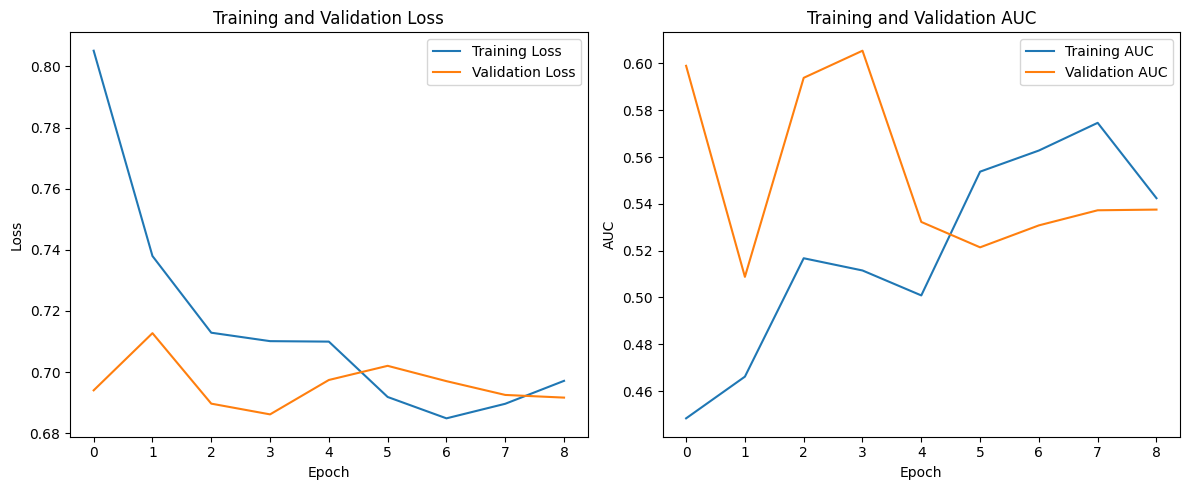

In [25]:
#Training
print("\nMemulai training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# Plot history training
def plot_history(history):
    plt.figure(figsize=(12, 5))
    
    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    # Plot AUC
    plt.subplot(1, 2, 2)
    plt.plot(history.history['auc'], label='Training AUC')
    plt.plot(history.history['val_auc'], label='Validation AUC')
    plt.title('Training and Validation AUC')
    plt.xlabel('Epoch')
    plt.ylabel('AUC')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.show()

plot_history(history)

## 12. 📈 Évaluation (validation & test)
*Mesure des performances : perte, accuracy et AUC.*

In [26]:
# Evaluasi pada validation set
print("\nEvaluasi pada validation set:")
val_loss, val_acc, val_auc = model.evaluate(X_val, y_val)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Validation AUC: {val_auc:.4f}")




Evaluasi pada validation set:
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.6194 - auc: 0.5878 - loss: 0.6872
Validation Loss: 0.6862
Validation Accuracy: 0.6239
Validation AUC: 0.6054


## 13. 🎯 Seuil de décision optimisé (*threshold tuning*)
*Recherche du meilleur seuil sur la **validation** (Youden's J) puis application au **test** pour équilibrer les décisions.*

In [27]:
# === Étape 2 : seuil de décision optimisé ===
from sklearn.metrics import roc_curve   # (déjà importé plus haut, on le remet par sécurité)

# 1) Les probabilités prédites par le modèle (des nombres entre 0 et 1)
val_prob    = model.predict(X_val).flatten()    # sur la VALIDATION
y_pred_prob = model.predict(X_test).flatten()   # sur le TEST

# 2) On cherche le meilleur seuil SUR LA VALIDATION (méthode Youden's J)
fpr, tpr, thr = roc_curve(y_val, val_prob)
best_thr = float(thr[np.argmax(tpr - fpr)])
print("Seuil par défaut : 0.5")
print("Seuil optimal    :", round(best_thr, 3))

# 3) On applique ce seuil optimal au TEST pour décider 0 ou 1
y_pred = (y_pred_prob > best_thr).astype(int)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 235ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Seuil par défaut : 0.5
Seuil optimal    : 0.507


In [28]:
# === Évaluation finale sur le TEST (une seule fois, seuil fixé sur la validation) ===
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, accuracy_score

test_auc  = roc_auc_score(y_test, y_pred_prob)     # AUC : indépendant du seuil
test_acc  = accuracy_score(y_test, y_pred)         # accuracy AU SEUIL OPTIMISÉ
test_bacc = balanced_accuracy_score(y_test, y_pred)

print(f"Seuil utilisé     : {best_thr:.3f}  (fixé sur la validation)")
print(f"Test AUC          : {test_auc:.4f}")
print(f"Test Accuracy     : {test_acc:.4f}")
print(f"Balanced accuracy : {test_bacc:.4f}\n")

print("Classification Report :")
print(classification_report(y_test, y_pred))
print("Confusion Matrix :")
print(confusion_matrix(y_test, y_pred))

Seuil utilisé     : 0.507  (fixé sur la validation)
Test AUC          : 0.5852
Test Accuracy     : 0.5812
Balanced accuracy : 0.5801

Classification Report :
              precision    recall  f1-score   support

         0.0       0.56      0.55      0.56        56
         1.0       0.60      0.61      0.60        61

    accuracy                           0.58       117
   macro avg       0.58      0.58      0.58       117
weighted avg       0.58      0.58      0.58       117

Confusion Matrix :
[[31 25]
 [24 37]]


## 14. 📋 Rapport de classification & matrice de confusion
*Détail des bonnes/mauvaises prédictions par classe.*

In [29]:
# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

         0.0       0.56      0.55      0.56        56
         1.0       0.60      0.61      0.60        61

    accuracy                           0.58       117
   macro avg       0.58      0.58      0.58       117
weighted avg       0.58      0.58      0.58       117



In [30]:
# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)


Confusion Matrix:
[[31 25]
 [24 37]]


## 15. 📉 Courbe ROC
*Visualise la capacité du modèle à séparer les deux classes (AUC : 0,5 = hasard, 1 = parfait).*

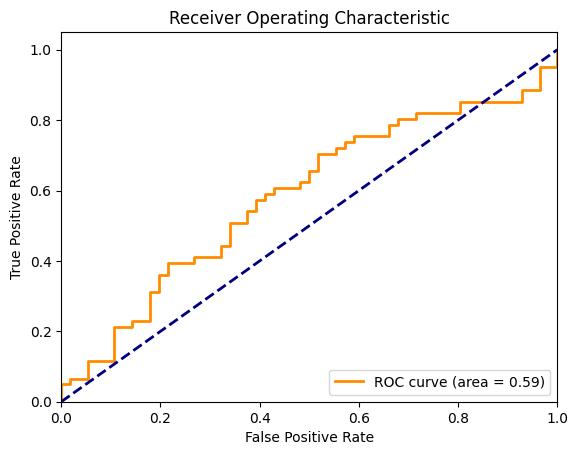

In [31]:
# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.savefig('roc_curve.png')
plt.show()

## 16: validation croisée 5-fold (le vrai verdict)

In [32]:
# === Étape 5 : validation croisée 5-fold (le vrai verdict) ===
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, balanced_accuracy_score

input_shape = X.shape[1:]                 # (16, 128, 128, 3)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

auc_scores, bacc_scores = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    print(f"\n===== Fold {fold}/5 =====")

    # 1) données de ce fold
    X_tr, X_va = X[train_idx], X[val_idx]
    y_tr, y_va = y[train_idx], y[val_idx]

    # 2) datasets (augmentation sur l'entraînement UNIQUEMENT) — ta fonction de l'étape 4
    tr_ds = make_dataset(X_tr, y_tr, training=True)
    va_ds = make_dataset(X_va, y_va, training=False)

    # 3) un NOUVEAU modèle repartant de zéro à chaque fold
    model_cv = build_3d_cnn(input_shape, num_classes=1)
    model_cv.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                     loss='binary_crossentropy',
                     metrics=[tf.keras.metrics.AUC(name='auc')])

    es = tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max',
                                          patience=6, restore_best_weights=True, verbose=0)

    # 4) entraînement (verbose=0 = silencieux, pour ne pas noyer l'affichage)
    model_cv.fit(tr_ds, validation_data=va_ds, epochs=EPOCHS,
                 callbacks=[es], verbose=0)

    # 5) prédictions sur le fold de test
    prob = model_cv.predict(X_va, verbose=0).flatten()

    # 6) AUC (ne dépend pas du seuil)
    fold_auc = roc_auc_score(y_va, prob)

    # 7) seuil optimisé (Youden's J) -> balanced accuracy
    fpr, tpr, thr = roc_curve(y_va, prob)
    best_thr = thr[np.argmax(tpr - fpr)]
    fold_bacc = balanced_accuracy_score(y_va, (prob > best_thr).astype(int))

    auc_scores.append(fold_auc)
    bacc_scores.append(fold_bacc)
    print(f"AUC = {fold_auc:.3f} | balanced accuracy = {fold_bacc:.3f}")

print("\n================ RÉSULTAT FINAL ================")
print(f"AUC moyen         : {np.mean(auc_scores):.3f} ± {np.std(auc_scores):.3f}")
print(f"Balanced accuracy : {np.mean(bacc_scores):.3f} ± {np.std(bacc_scores):.3f}")


===== Fold 1/5 =====
AUC = 0.633 | balanced accuracy = 0.624

===== Fold 2/5 =====
AUC = 0.606 | balanced accuracy = 0.621

===== Fold 3/5 =====
AUC = 0.660 | balanced accuracy = 0.665

===== Fold 4/5 =====
AUC = 0.610 | balanced accuracy = 0.615

===== Fold 5/5 =====
AUC = 0.542 | balanced accuracy = 0.565

================ RÉSULTAT FINAL ================
AUC moyen         : 0.610 ± 0.039
Balanced accuracy : 0.618 ± 0.032


## 17. 🤝 Ensemble (levier 2) — résultat final
   *Moyenne de 5 modèles pour un résultat plus haut et plus stable — le chiffre à présenter.*

In [33]:
# === Levier 2 : Ensembling (faire voter plusieurs modèles) ===
from sklearn.metrics import (roc_auc_score, roc_curve, balanced_accuracy_score,
                             accuracy_score, confusion_matrix, classification_report)

N_MODELS = 5
input_shape = X_train.shape[1:]

val_probs_all, test_probs_all = [], []

for i in range(N_MODELS):
    print(f"--- Entraînement du modèle {i+1}/{N_MODELS} ---")
    tf.random.set_seed(100 + i)          # une graine différente par modèle

    m = build_3d_cnn(input_shape, num_classes=1)
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='binary_crossentropy',
              metrics=[tf.keras.metrics.AUC(name='auc')])
    es = tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max',
                                          patience=6, restore_best_weights=True, verbose=0)

    tr_ds = make_dataset(X_train, y_train, training=True)
    va_ds = make_dataset(X_val,   y_val,   training=False)
    m.fit(tr_ds, validation_data=va_ds, epochs=EPOCHS, callbacks=[es], verbose=0)

    val_probs_all.append(m.predict(X_val,  verbose=0).flatten())
    test_probs_all.append(m.predict(X_test, verbose=0).flatten())

# Le "vote" de l'ensemble = moyenne des probabilités
val_prob_ens  = np.mean(val_probs_all,  axis=0)
test_prob_ens = np.mean(test_probs_all, axis=0)

# Seuil optimisé sur la validation, appliqué au test
from sklearn.metrics import accuracy_score
# seuil qui maximise l'ACCURACY sur la validation (métrique visée par le prof)
grille = np.linspace(0.05, 0.95, 181)
accs   = [accuracy_score(y_val, (val_prob_ens > t).astype(int)) for t in grille]
best_thr = float(grille[np.argmax(accs)])
y_pred_ens = (test_prob_ens > best_thr).astype(int)

print(f"\n============ ENSEMBLE ({N_MODELS} modèles) ============")
print(f"Seuil utilisé     : {best_thr:.3f}")
print(f"Test AUC          : {roc_auc_score(y_test, test_prob_ens):.4f}")
print(f"Test Accuracy     : {accuracy_score(y_test, y_pred_ens):.4f}")
print(f"Balanced accuracy : {balanced_accuracy_score(y_test, y_pred_ens):.4f}")
print("\nConfusion Matrix :")
print(confusion_matrix(y_test, y_pred_ens))
print("\nClassification Report :")
print(classification_report(y_test, y_pred_ens))

--- Entraînement du modèle 1/5 ---
--- Entraînement du modèle 2/5 ---
--- Entraînement du modèle 3/5 ---
--- Entraînement du modèle 4/5 ---
--- Entraînement du modèle 5/5 ---

============ ENSEMBLE (5 modèles) ============
Seuil utilisé     : 0.490
Test AUC          : 0.6437
Test Accuracy     : 0.6068
Balanced accuracy : 0.6017

Confusion Matrix :
[[27 29]
 [17 44]]

Classification Report :
              precision    recall  f1-score   support

         0.0       0.61      0.48      0.54        56
         1.0       0.60      0.72      0.66        61

    accuracy                           0.61       117
   macro avg       0.61      0.60      0.60       117
weighted avg       0.61      0.61      0.60       117



## 18. 💾 Sauvegarde du modèle
*Enregistrement du modèle entraîné pour réutilisation.*

In [34]:
# Simpan model akhir
model.save('final_model.h5')
print("\nModel akhir disimpan sebagai 'final_model.h5'")


Model akhir disimpan sebagai 'final_model.h5'
